In [1]:
import matplotlib.pyplot as plt
import numpy as np

# If you have OASIS installed (you do in CALI):
from oasis.functions import deconvolve

np.random.seed(0)

/Users/fdrgsp/Documents/git/cali/.venv/lib/python3.13/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


In [4]:
# ---------------------------------------------------------------------
# 1. SIMULATE SPIKE TRAINS
# ---------------------------------------------------------------------
T = 1000  # number of frames
dt = 0.1  # s per frame (so 100 s total)
time = np.arange(T) * dt

# Helper: create sparse spike train
def make_spike_train(base_rate_hz=0.05, bursts=None, jitter=0):
    """
    base_rate_hz: background Poisson rate
    bursts: list of (center_frame,) where we force spikes
    jitter: ± jitter (frames) around burst centers.
    """
    spikes = np.zeros(T, dtype=float)
    # background Poisson
    p = base_rate_hz * dt  # prob per frame
    spikes[np.random.rand(T) < p] = 1.0

    if bursts is not None:
        for c in bursts:
            j = np.random.randint(-jitter, jitter + 1) if jitter > 0 else 0
            idx = np.clip(c + j, 0, T - 1)
            spikes[idx] = 1.0
    return spikes

# ---------------------------------------------------------------------
# 2. GENERATE CALCIUM ΔF/F TRACES
# ---------------------------------------------------------------------
def spikes_to_dff(spikes, tau_decay=1.5, amp=1.0, noise_sd=0.05):
    """
    Simple exponential convolution + noise, then ΔF/F.
    tau_decay in seconds.
    """
    tau_frames = tau_decay / dt
    klen = int(5 * tau_frames)
    kernel = np.exp(-np.arange(klen) / tau_frames)

    ca = np.convolve(spikes, kernel, mode="full")[:T]
    F = 1.0 + amp * ca  # baseline 1.0
    F_noisy = F + np.random.normal(0, noise_sd, size=F.shape)

    F0 = np.percentile(F_noisy, 20)  # pseudo-baseline
    dff = (F_noisy - F0) / F0
    return dff

# ---------------------------------------------------------------------
# 2. GENERATE CALCIUM ΔF/F TRACES
# ---------------------------------------------------------------------
def spikes_to_dff(spikes, tau_decay=1.5, amp=1.0, noise_sd=0.05):
    """
    Simple exponential convolution + noise, then ΔF/F.
    tau_decay in seconds.
    """
    tau_frames = tau_decay / dt
    klen = int(5 * tau_frames)
    kernel = np.exp(-np.arange(klen) / tau_frames)

    ca = np.convolve(spikes, kernel, mode="full")[:T]
    F = 1.0 + amp * ca  # baseline 1.0
    F_noisy = F + np.random.normal(0, noise_sd, size=F.shape)

    F0 = np.percentile(F_noisy, 20)  # pseudo-baseline
    dff = (F_noisy - F0) / F0
    return dff

In [5]:
# Shared bursts for cell 1 & 2
burst_frames = [200, 400, 650, 820]

spikes_true_1 = make_spike_train(0.02, bursts=burst_frames, jitter=0)
spikes_true_2 = make_spike_train(0.02, bursts=burst_frames, jitter=2)  # slight jitter
spikes_true_3 = make_spike_train(0.05, bursts=None)  # mostly independent

spikes_true = [spikes_true_1, spikes_true_2, spikes_true_3]

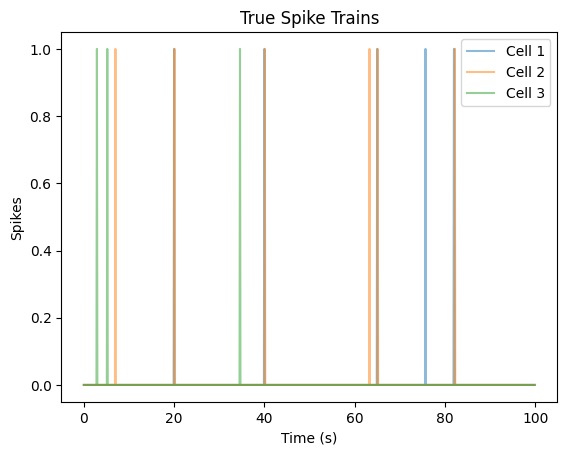

In [11]:
plt.plot(time, spikes_true_1, label="Cell 1", alpha=0.5)
plt.plot(time, spikes_true_2, label="Cell 2", alpha=0.5)
plt.plot(time, spikes_true_3, label="Cell 3", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Spikes")
plt.title("True Spike Trains")
plt.legend()
plt.show()

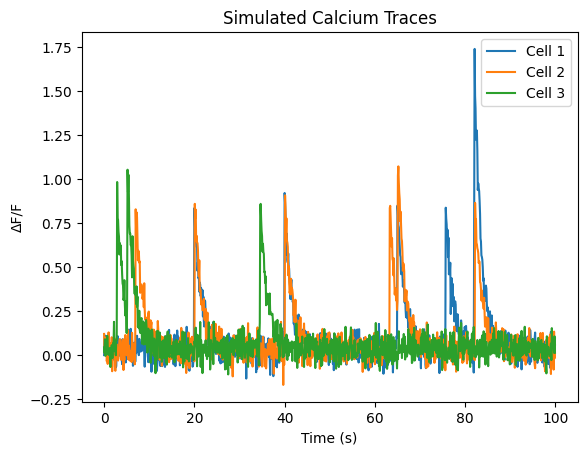

In [13]:
dff_traces = [
    spikes_to_dff(s, tau_decay=1.5, amp=0.8, noise_sd=0.05) for s in spikes_true
]

plt.plot(time, dff_traces[0], label="Cell 1")
plt.plot(time, dff_traces[1], label="Cell 2")
plt.plot(time, dff_traces[2], label="Cell 3")
plt.xlabel("Time (s)")
plt.ylabel("ΔF/F")
plt.title("Simulated Calcium Traces")
plt.legend()
plt.show()

/Users/fdrgsp/Documents/git/cali/.venv/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


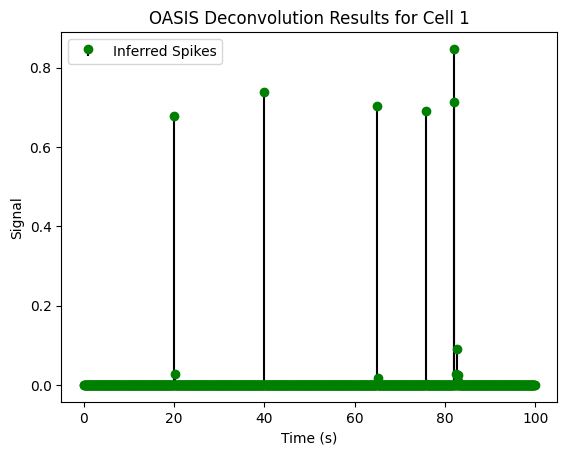

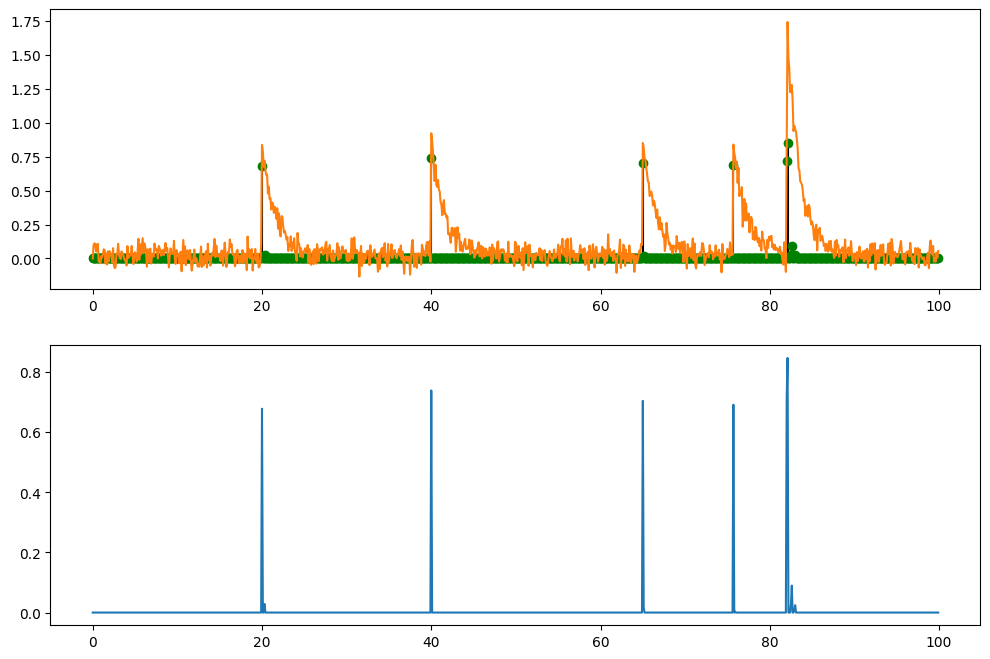

In [40]:
# ---------------------------------------------------------------------
# 3. OASIS DECONVOLUTION
# ---------------------------------------------------------------------
dec_traces = []
inf_spikes = []

for dff in dff_traces:
    # OASIS returns: C, s, b, g, lam
    C, s, _, _, _ = deconvolve(dff, penalty=1)  # simple AR(1) model
    dec_traces.append(C)
    inf_spikes.append(s)

# Convert to arrays (3 x T)
dff_arr = np.vstack(dff_traces)
dec_arr = np.vstack(dec_traces)
spk_arr = np.vstack(inf_spikes)

# plt.plot(dff_arr[0], label="ΔF/F Cell 1")
# plt.plot(dec_arr[0], label="Deconvolved Ca Cell 1")
# plt.plot(spk_arr[0], label="Inferred Spikes Cell 1")
plt.stem(
    time,
    spk_arr[0],
    linefmt="-k",
    markerfmt="go",
    basefmt=" ",
    label="Inferred Spikes",
)
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("OASIS Deconvolution Results for Cell 1")
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.stem(
    time,
    spk_arr[0],
    linefmt="-k",
    markerfmt="go",
    basefmt=" ",
    label="Inferred Spikes",
)
plt.plot(time, dff_arr[0])
plt.subplot(2, 1, 2)
plt.plot(time, spk_arr[0])
# for i in range(3):
#     plt.subplot(3, 1, i + 1)
#     plt.plot(time, dff_arr[i], label="ΔF/F", color="blue", alpha=0.5)
#     plt.plot(time, dec_arr[i], label="Deconvolved Ca", color="orange")
#     plt.stem(
#         time,
#         spk_arr[i],
#         linefmt="red",
#         markerfmt="ro",
#         basefmt=" ",
#         label="Inferred Spikes",
#     )
#     plt.title(f"Cell {i + 1}")
#     plt.xlabel("Time (s)")
#     plt.ylabel("Signal")
#     plt.legend()
# plt.tight_layout()
# plt.show()

